In [1]:
!pip install mne

In [2]:
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from mne.decoding import SlidingEstimator

# --- 1. SETUP PATHS ---
basic_path = 'project/ds006761'
subject_id = 'sub-01'
bdf_file = f'{basic_path}/{subject_id}/eeg/{subject_id}_task-RPS_eeg.bdf'
events_file = f'{basic_path}/{subject_id}/eeg/{subject_id}_task-RPS_events.tsv'

print(f"Processing {subject_id}...")

# --- 2. LOAD RAW EEG DATA ---
# Preload=True loads data into RAM for faster processing
raw = mne.io.read_raw_bdf(bdf_file, preload=True)

# BioSemi 64 channel names might need standardization (optional)
# For now, we assume channels 0-63 are Player 1 (as per your check)
# We will focus on Player 1's channels for decoding THEIR response.
picks = list(range(0, 64))

Processing sub-01...
Extracting EDF parameters from /Users/abijithlakshmanan/Desktop/Sem 3/EEG/EEG_PROJECT/project/ds006761/sub-01/eeg/sub-01_task-RPS_eeg.bdf...
BDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 7514111  =      0.000 ...  3669.000 secs...


In [3]:
# --- 3. PRE-PROCESSING ---

# A. Filter (CHANGE #3: 0.1Hz High-Pass)
# This removes slow drifts (sweat/skin potentials) that confuse classifiers
raw.filter(l_freq=0.1, h_freq=None, picks=picks)

# B. Re-reference (Paper Method: Common Average)
# We set reference only on the EEG channels we are using
raw.set_eeg_reference('average', projection=False)

print("Pre-processing complete: Filtered (0.1Hz) and Re-referenced.")

Filtering a subset of channels. The highpass and lowpass values in the measurement info will not be updated.
Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 0.1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Filter length: 67585 samples (33.000 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:   11.5s
[Parallel(n_jobs=1)]: Done  64 out of  64 | elapsed:   43.7s finished


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Pre-processing complete: Filtered (0.1Hz) and Re-referenced.


In [4]:
# --- REPLACEMENT CODE FOR STEP 3 & 4 ---

# 1. Load the behavioral log (The Answer Key)
events_df = pd.read_csv(events_file, sep='\t')

print("Using behavioral log to create events...")

# 2. Create the MNE Events Array manually from the TSV
# BIDS .tsv files store onsets in seconds. We must convert them to "samples".
sfreq = raw.info['sfreq']
onsets = events_df['onset'].values
onsets_samples = (onsets * sfreq).astype(int)

# Get the labels (1=Rock, 2=Paper, 3=Scissors)
labels = events_df['player1_resp'].values.astype(int)

# Stack them into the format MNE needs: [Sample_Index, 0, Event_ID]
events = np.column_stack((onsets_samples, np.zeros_like(onsets_samples), labels))

# 3. Filter for valid trials
# We only want rows where the label is 1, 2, or 3.
valid_indices = np.isin(events[:, 2], [1, 2, 3])
events = events[valid_indices]

print(f"Refined Events: Found {len(events)} valid trials with IDs: {np.unique(events[:, 2])}")

# --- EPOCHING (With corrected events) ---
tmin, tmax = -0.2, 2.0

# Note: We pass 'event_id=None' because our events array already has the correct integers (1,2,3)
epochs = mne.Epochs(raw, events, event_id=None, tmin=tmin, tmax=tmax, 
                    baseline=(-0.2, 0), picks=picks, preload=True, verbose=True)

# Downsample to 256 Hz
epochs.resample(256)

print("Epoching complete.")

Using behavioral log to create events...
Refined Events: Found 480 valid trials with IDs: [1 2 3]
Not setting metadata
480 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 480 events and 4507 original time points ...
0 bad epochs dropped
Epoching complete.


In [5]:
# --- 5. EPOCHING ---

# Define the window: Decision Phase (-0.2 to 2.0s)
tmin, tmax = -0.2, 2.0

# Create Epochs
# picks=picks ensures we only use Player 1's 64 channels
epochs = mne.Epochs(raw, events, event_id=None, tmin=tmin, tmax=tmax, 
                    baseline=(-0.2, 0), picks=picks, preload=True, verbose=False)

# Downsample to 256 Hz (Matches Paper)
epochs.resample(256)

print(f"Epochs created: {len(epochs)} trials x {len(epochs.ch_names)} channels x {len(epochs.times)} time points")

Epochs created: 480 trials x 64 channels x 563 time points


In [6]:
# --- 6. CREATE PSEUDO-TRIALS (SNR BOOST) ---

def create_pseudo_trials(X, y, n_avg=4):
    """
    Groups trials by class, shuffles them, and averages every 4 trials.
    """
    unique_classes = np.unique(y)
    X_pseudo, y_pseudo = [], []

    for cls in unique_classes:
        # Get all trials for this class (e.g., all Rocks)
        indices = np.where(y == cls)[0]
        np.random.shuffle(indices) # Randomize order
        
        # Truncate to be divisible by n_avg
        n_keep = len(indices) - (len(indices) % n_avg)
        indices = indices[:n_keep]
        
        # Reshape and Mean: (N_groups, 4, Chan, Time) -> (N_groups, Chan, Time)
        # We perform the mean over the "trials" dimension (axis 1)
        cls_data = X[indices]
        cls_data_avg = cls_data.reshape(-1, n_avg, *cls_data.shape[1:]).mean(axis=1)
        
        X_pseudo.append(cls_data_avg)
        y_pseudo.extend([cls] * len(cls_data_avg))
        
    return np.vstack(X_pseudo), np.array(y_pseudo)

# Get data as numpy arrays
X = epochs.get_data()
y = epochs.events[:, -1]

# Apply the function
X_ps, y_ps = create_pseudo_trials(X, y, n_avg=4)
print(f"Pseudo-trials created. New shape: {X_ps.shape}")

Pseudo-trials created. New shape: (119, 64, 563)


In [7]:
# --- 7. DECODING (CORRECTED) ---
from mne.decoding import cross_val_multiscore # <--- IMPORT THIS

# Define Classifier (SVM)
clf = make_pipeline(StandardScaler(), SVC(kernel='linear', probability=True))

# Define Cross-Validation
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Define Sliding Window
slider = SlidingEstimator(clf, scoring='accuracy', n_jobs=1) # Set n_jobs=1 to avoid joblib errors

# Run Decoding using MNE's multiscore function
print("Running SVM decoding... this may take a minute.")

# FIX: Use cross_val_multiscore instead of cross_val_score
scores = cross_val_multiscore(slider, X_ps, y_ps, cv=cv, n_jobs=1)

# Average across the 10 folds
# The output shape of scores is (n_folds, n_time_points)
mean_scores = np.mean(scores, axis=0)

print("Decoding complete.")

Running SVM decoding... this may take a minute.


/Users/abijithlakshmanan/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Python(76302) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
100%|██████████| Fitting SlidingEstimator : 563/563 [00:06<00:00,   87.69it/s]
100%|██████████| Fitting SlidingEstimator : 563/563 [00:05<00:00,   95.84it/s]
100%|██████████| Fitting SlidingEstimator : 563/563 [00:05<00:00,  111.49it/s]
100%|██████████| Fitting SlidingEstimator : 563/563 [00:06<00:00,   82.61it/s]
100%|██████████| Fitting SlidingEstimator : 563/563 [00:05<00:00,   94.21it/s]
100%|██████████| Fitting SlidingEstimator : 563/563 [00:06<00:00,   80.85it/s]
100%|██████████| Fitting SlidingEstimator : 563/563 [00:06<00:00,   89.98it/s]
100%|██████████| Fitting SlidingEstimator : 563/563 [00:06<00:00,   88.51it

Decoding complete.


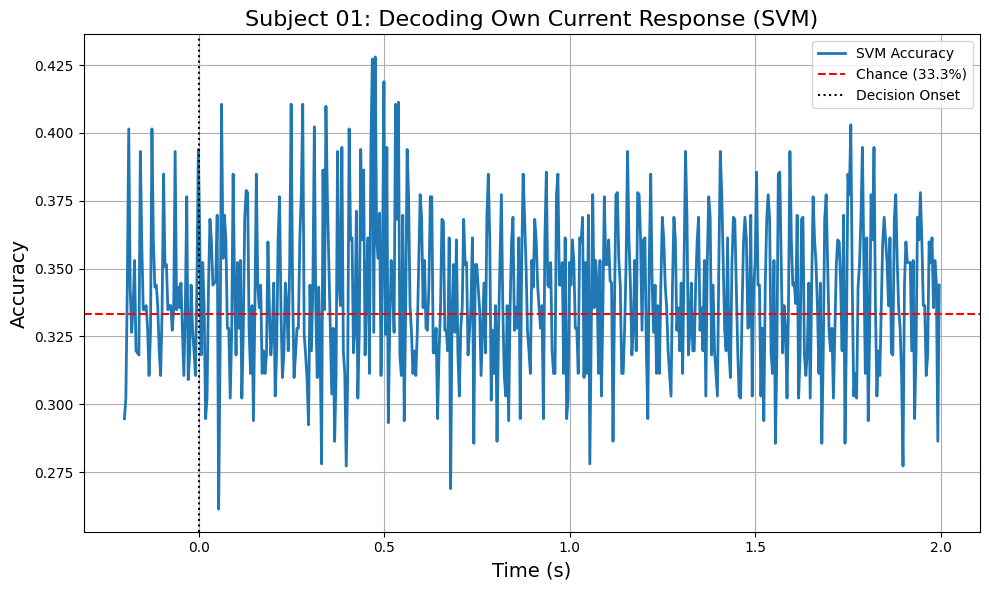

In [8]:
# --- 8. PLOT RESULTS ---

time_points = epochs.times

plt.figure(figsize=(10, 6))
plt.plot(time_points, mean_scores, label='SVM Accuracy', linewidth=2)
plt.axhline(1/3, color='r', linestyle='--', label='Chance (33.3%)')
plt.axvline(0, color='k', linestyle=':', label='Decision Onset')

plt.title(f'Subject 01: Decoding Own Current Response (SVM)', fontsize=16)
plt.xlabel('Time (s)', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [10]:
# --- 9. PREPARE PREVIOUS RESPONSE TARGETS ---

print("Setting up for 'Previous Response' decoding...")

# 1. Reload events (to be safe)
events_df = pd.read_csv(events_file, sep='\t')

# 2. Shift the responses by 1 to get the "Previous" move
# Trial N's label becomes Trial N-1's response
events_df['prev_resp'] = events_df['player1_resp'].shift(1)

# 3. Drop the first trial (it has no previous move) and any invalid ones
# We keep only rows where the PREVIOUS response was 1, 2, or 3
valid_prev_trials = events_df[events_df['prev_resp'].isin([1, 2, 3])].copy()

# 4. Create new MNE Events array for Previous Response
# Use the 'onset' of the CURRENT trial (brain data), but the label of the PREVIOUS response
sfreq = raw.info['sfreq']
onsets_prev = valid_prev_trials['onset'].values
onsets_prev_samples = (onsets_prev * sfreq).astype(int)
labels_prev = valid_prev_trials['prev_resp'].values.astype(int)

# Stack: [Sample, 0, Label]
events_prev = np.column_stack((onsets_prev_samples, np.zeros_like(onsets_prev_samples), labels_prev))

print(f"Created {len(events_prev)} trials for Previous Response decoding.")

# --- 10. RE-EPOCH & DECODE (PREVIOUS RESPONSE) ---

# A. Epoch the raw data again with the new events
# (We reuse the 'raw' object which is already filtered)
epochs_prev = mne.Epochs(raw, events_prev, event_id=None, tmin=tmin, tmax=tmax,
                         baseline=(-0.2, 0), picks=picks, preload=True, verbose=False)
epochs_prev.resample(256)

# B. Create Pseudo-trials for the new epochs
X_prev = epochs_prev.get_data()
y_prev = epochs_prev.events[:, -1]
X_ps_prev, y_ps_prev = create_pseudo_trials(X_prev, y_prev, n_avg=4)

# C. Run Decoding
print("Running SVM decoding for PREVIOUS Response...")
scores_prev = cross_val_multiscore(slider, X_ps_prev, y_ps_prev, cv=cv, n_jobs=1)
mean_scores_prev = np.mean(scores_prev, axis=0)

print("Previous Response decoding complete.")

Setting up for 'Previous Response' decoding...
Created 479 trials for Previous Response decoding.
Running SVM decoding for PREVIOUS Response...


100%|██████████| Fitting SlidingEstimator : 563/563 [00:04<00:00,  116.58it/s]
100%|██████████| Fitting SlidingEstimator : 563/563 [00:05<00:00,  110.22it/s]
100%|██████████| Fitting SlidingEstimator : 563/563 [00:05<00:00,  109.29it/s]
100%|██████████| Fitting SlidingEstimator : 563/563 [00:06<00:00,   81.94it/s]
100%|██████████| Fitting SlidingEstimator : 563/563 [00:05<00:00,  107.94it/s]
100%|██████████| Fitting SlidingEstimator : 563/563 [00:05<00:00,   95.83it/s]
100%|██████████| Fitting SlidingEstimator : 563/563 [00:06<00:00,   93.14it/s]
100%|██████████| Fitting SlidingEstimator : 563/563 [00:05<00:00,   96.21it/s]
100%|██████████| Fitting SlidingEstimator : 563/563 [00:05<00:00,  112.06it/s]
100%|██████████| Fitting SlidingEstimator : 563/563 [00:04<00:00,  123.63it/s]


Previous Response decoding complete.


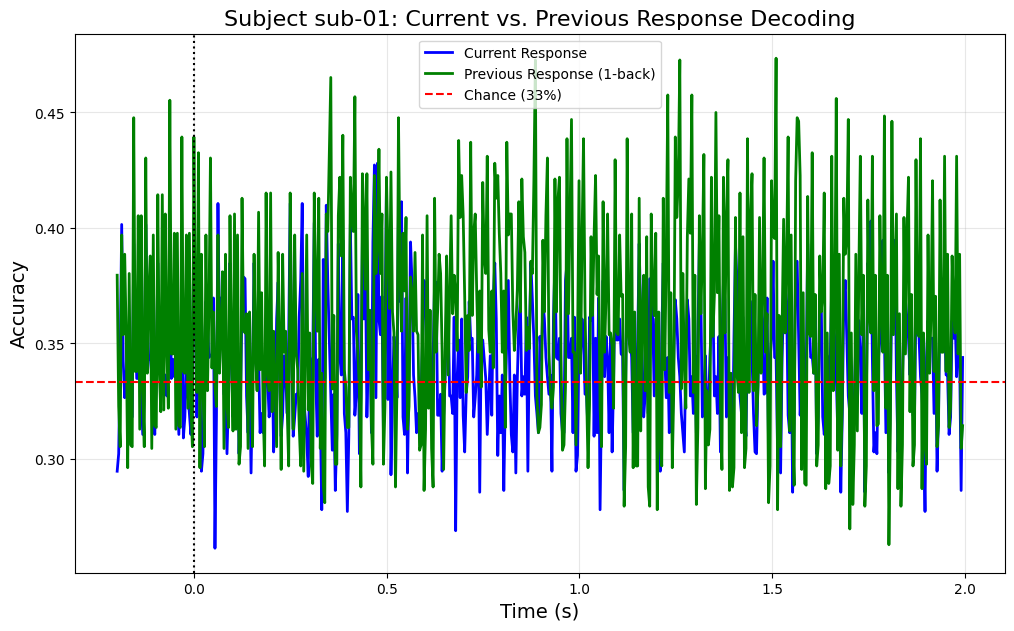

In [11]:
# --- 11. COMBINED PLOT ---

plt.figure(figsize=(12, 7))

# Plot Current (from Step 7)
plt.plot(time_points, mean_scores, label='Current Response', color='blue', linewidth=2)

# Plot Previous (from Step 10)
# Note: epochs_prev.times should be identical to time_points
plt.plot(epochs_prev.times, mean_scores_prev, label='Previous Response (1-back)', color='green', linewidth=2, linestyle='-')

# Add Chance & Onset
plt.axhline(1/3, color='red', linestyle='--', label='Chance (33%)')
plt.axvline(0, color='black', linestyle=':')

plt.title(f'Subject {subject_id}: Current vs. Previous Response Decoding', fontsize=16)
plt.xlabel('Time (s)', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()